# Fixed-Support Right-Censored Demo

This notebook runs one reproducible right-censored example with three fits built from the same Stage 1 CV-IPCW working model:

1. `CV-IPCW`: the existing IPCW-HAL initializer tuned by IPCW validation loss.
2. `EM`: a direct no-oversmooth EM refit that inherits the Stage 1 norm constraint and support.
3. `Observed L1`: a notebook-local observed-data L1-constrained parametric MLE that keeps the Stage 1 working support fixed and never thresholds knots at the end.

The third fit is local to this notebook so we can prototype the fixed-support observed-data estimator without changing the package API first.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right.comparison import (
    evaluate_survival_on_grid,
    simulate_beta_uniform_right_censored,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.right.observed_mle import RightCensoredObservedProjectedGDEstimator
from haldensity.censoring.tuners.right_tuners import (
    RightCensoredEMTuner,
    RightCensoredInitTuner,
)
from haldensity.estimation.base_estimator import BaseEstimator

SEED = 3
N = 200
CV_FOLDS = 5
N_TRIALS = 25
N_GRID_POINTS = 100
STAGE1_OVERRIDES = {
    "basis_order": [0],
    "norm_constraint": {"low": 0.1, "high": 12.0, "log": False},
}
EM_M_IMPUTATIONS = 40
EM_MAX_ITER = 10
EM_TOL = 1e-3
OBS_L1_LEARNING_RATE = 0.1
OBS_L1_MAX_ITER = 500
OBS_L1_LL_TOL = 1e-4

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Notebook-local observed L1 fit

The package already has the observed-data smooth log-likelihood and projected-gradient machinery. For this demo we only change the support semantics:

- the support is supplied explicitly by `working_grid_points`,
- `fit()` always uses that fixed support,
- the L1-ball projection is kept,
- the final coefficients are **not** thresholded to redefine the support.

So this behaves like a fixed-working-model observed-data HAL-MLE with an L1 constraint.

In [2]:
class RightCensoredObservedL1MLELocal(RightCensoredObservedProjectedGDEstimator):
    """Notebook-local fixed-support observed-data L1 MLE."""

    def __init__(
        self,
        *,
        working_grid_points,
        norm_constraint,
        basis_order,
        n_grid_points,
        learning_rate,
        n_iterations,
        ll_change_tol,
        include_intercept_in_constraint=False,
        tol=1e-6,
        near_zero_tol=1e-8,
        min_tail_mass=1e-12,
    ):
        working_grid = np.sort(np.unique(np.asarray(working_grid_points, dtype=float)))
        if working_grid.size == 0:
            raise ValueError("working_grid_points must be non-empty")

        self.working_grid_points = working_grid
        self.near_zero_tol = float(near_zero_tol)
        self.penalized_l1_norm_ = None
        self.n_near_zero_coeffs_ = None
        self.n_exact_zero_coeffs_ = None
        self.constraint_active_ = None
        self.n_active_knot_coeffs_ = None

        super().__init__(
            norm_constraint=float(norm_constraint),
            learning_rate=float(learning_rate),
            n_iterations=int(n_iterations),
            tol=float(tol),
            ll_change_tol=float(ll_change_tol),
            n_grid_points=int(n_grid_points),
            basis_order=int(basis_order),
            min_tail_mass=float(min_tail_mass),
            include_intercept_in_constraint=bool(include_intercept_in_constraint),
            use_nesterov=True,
        )

    def fit(self, data, *, time_col="T", delta_col="Delta", warm_start_theta=None, **kwargs):
        return super().fit(
            data,
            time_col=time_col,
            delta_col=delta_col,
            grid_points_override=self.working_grid_points,
            warm_start_theta=warm_start_theta,
        )

    def observed_loglik_and_gradient(self, theta, *, compute_grad=True):
        loss, grad = self._smooth_loss_and_grad(
            np.asarray(theta, dtype=float),
            compute_grad=compute_grad,
        )
        return -float(loss), (None if grad is None else -np.asarray(grad, dtype=float))

    def _finalize_fit(self, theta, grid_points_hal):
        self.theta_hat = np.asarray(theta, dtype=float).copy()
        self._grid_points_hal = self.working_grid_points.copy()
        self.grid_points_hal_selected = self.working_grid_points.copy()

        n_out = int(max(self.n_grid_points, 2000)) if self.basis_order == 0 else int(self.n_grid_points)
        output_grid = np.linspace(0.0, 1.0, n_out)
        output_mid = (output_grid[:-1] + output_grid[1:]) / 2.0
        delta_out = output_grid[1:] - output_grid[:-1]
        density_out, _, max_log, norm_const = BaseEstimator.normalized_hal_density(
            output_mid,
            self.theta_hat,
            self._grid_points_hal,
            self.basis_order,
            delta=delta_out,
        )

        self._norm_shift = max_log
        self._norm_Z = norm_const
        self._density_midpoints = density_out
        self.grid_midpoints = output_mid
        self.delta_j = delta_out
        self.grid_points = output_grid
        self.is_fitted = True
        self.fitted_theta_dict = {
            name: float(value) for name, value in zip(self.basis_names, self.theta_hat)
        }

        start_idx = 0 if self.include_intercept_in_constraint else 1
        penalized_block = self.theta_hat[start_idx:]
        self.penalized_l1_norm_ = float(np.sum(np.abs(penalized_block))) if penalized_block.size else 0.0
        self.n_near_zero_coeffs_ = int(np.sum(np.abs(penalized_block) <= self.near_zero_tol)) if penalized_block.size else 0
        self.n_exact_zero_coeffs_ = int(np.sum(penalized_block == 0.0)) if penalized_block.size else 0
        self.constraint_active_ = bool(
            np.isclose(
                self.penalized_l1_norm_,
                self.norm_constraint,
                atol=max(1e-8, 10.0 * self.tol),
                rtol=0.0,
            )
        )

        poly_cols = self.basis_order if self.basis_order > 0 else 0
        knot_start = min(self.theta_hat.size, 1 + poly_cols)
        knot_block = self.theta_hat[knot_start:]
        self.n_active_knot_coeffs_ = int(np.sum(np.abs(knot_block) > self.tol)) if knot_block.size else 0

    def get_results(self):
        base = super().get_results()
        base.update(
            {
                "working_grid_points": self.working_grid_points.copy(),
                "penalized_l1_norm": float(self.penalized_l1_norm_),
                "n_near_zero_coeffs": int(self.n_near_zero_coeffs_),
                "n_exact_zero_coeffs": int(self.n_exact_zero_coeffs_),
                "constraint_active": bool(self.constraint_active_),
                "n_active_knot_coeffs": int(self.n_active_knot_coeffs_),
            }
        )
        return base


def density_mass(estimator) -> float:
    grid_mid, density = estimator.get_density()
    return float(np.sum(density * estimator.delta_j))

In [3]:
simulation = simulate_beta_uniform_right_censored(n=N, seed=SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_tuner = RightCensoredInitTuner(
    data=observed_data,
    cv_folds=CV_FOLDS,
    random_state=SEED,
    n_grid_points=N_GRID_POINTS,
    param_overrides=STAGE1_OVERRIDES,
    use_conservative_adjustment=False,
    silent=True,
    validation_metric="ipcw_loglik",
)
stage1_result = stage1_tuner.optimize(n_trials=N_TRIALS)
stage1_est = stage1_result.estimator
stage1_support = np.asarray(stage1_est.grid_points_hal_selected, dtype=float).copy()

run_info = pd.DataFrame(
    [
        {
            "seed": SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_result.best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_result.best_params["norm_constraint"]),
            "stage1_selected_knots": int(stage1_support.size),
        }
    ]
)

display(observed_data.head())
display(run_info)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,T,Delta
0,0.391540,0
1,0.448111,0
2,0.266991,1
3,0.564418,0
4,0.400249,1


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_selected_knots
0,3,200,104,96,0,3.438638,8


In [4]:
stage2_tuner = RightCensoredEMTuner(
    data=observed_data,
    stage1_estimator=stage1_est,
    random_state=SEED,
    n_grid_points=N_GRID_POINTS,
    do_over_smooth=False,
    em_m_imputations=EM_M_IMPUTATIONS,
    em_max_em_iter=EM_MAX_ITER,
    em_tol=EM_TOL,
    em_norm_factor=1.0,
    silent=True,
)
stage2_result = stage2_tuner.optimize()
stage2_est = stage2_result.estimator

stage3_est = RightCensoredObservedL1MLELocal(
    working_grid_points=stage1_support,
    norm_constraint=float(stage1_est.norm_constraint),
    basis_order=int(stage1_est.basis_order),
    n_grid_points=N_GRID_POINTS,
    learning_rate=OBS_L1_LEARNING_RATE,
    n_iterations=OBS_L1_MAX_ITER,
    ll_change_tol=OBS_L1_LL_TOL,
    include_intercept_in_constraint=False,
).fit(observed_data)

stage2_support_matches_stage1 = np.array_equal(
    np.asarray(stage2_est.grid_points_hal_selected, dtype=float),
    stage1_support,
)
stage3_grid_matches_stage1 = np.array_equal(
    np.asarray(stage3_est._grid_points_hal, dtype=float),
    stage1_support,
)
stage3_support_matches_stage1 = np.array_equal(
    np.asarray(stage3_est.grid_points_hal_selected, dtype=float),
    stage1_support,
)

support_checks = pd.DataFrame(
    [
        {
            "stage2_support_matches_stage1": stage2_support_matches_stage1,
            "stage3__grid_points_hal_matches_stage1": stage3_grid_matches_stage1,
            "stage3_selected_support_matches_stage1": stage3_support_matches_stage1,
        }
    ]
)

display(support_checks)

,stage2_support_matches_stage1,stage3__grid_points_hal_matches_stage1,stage3_selected_support_matches_stage1
0,True,True,True


In [5]:
comparison_rows = []
for label, estimator in [
    ("CV-IPCW", stage1_est),
    ("EM inherit support", stage2_est),
    ("Observed L1 parametric MLE", stage3_est),
]:
    results = estimator.get_results()
    row = {
        "method": label,
        "observed_loglik": incomplete_loglik(estimator, observed_data),
        "density_mass": density_mass(estimator),
        "basis_order": int(estimator.basis_order),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "working_knots": int(len(np.asarray(estimator._grid_points_hal, dtype=float))),
        "reported_knots": int(len(np.asarray(results["grid_points_hal_selected"], dtype=float))),
    }
    if "penalized_l1_norm" in results:
        row.update(
            {
                "penalized_l1_norm": float(results["penalized_l1_norm"]),
                "constraint_active": bool(results["constraint_active"]),
                "n_near_zero_coeffs": int(results["n_near_zero_coeffs"]),
                "n_exact_zero_coeffs": int(results["n_exact_zero_coeffs"]),
                "n_active_knot_coeffs": int(results["n_active_knot_coeffs"]),
            }
        )
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

config_df = pd.DataFrame(
    [
        {
            "stage1_validation_metric": "ipcw_loglik",
            "stage1_best_params": stage1_result.best_params,
            "stage2_best_params": stage2_result.best_params,
            "observed_l1_working_knots": stage1_support.tolist(),
        }
    ]
)

display(comparison_df)
display(config_df)

,method,observed_loglik,density_mass,basis_order,norm_constraint,working_knots,reported_knots,penalized_l1_norm,constraint_active,n_near_zero_coeffs,n_exact_zero_coeffs,n_active_knot_coeffs
0,CV-IPCW,-15.754540,1.0,0,3.438638,106,8,NaN,NaN,NaN,NaN,NaN
1,EM inherit support,-14.813004,1.0,0,3.438638,8,8,NaN,NaN,NaN,NaN,NaN
2,Observed L1 parametric MLE,-14.234957,1.0,0,3.438638,8,8,3.438638,True,2.0,2.0,6.0


,stage1_validation_metric,stage1_best_params,stage2_best_params,observed_l1_working_knots
0,ipcw_loglik,"{'basis_order': 0, 'norm_constraint': 3.438638...","{'oversmooth_factor': 1.0, 'em_norm_factor': 1.0}","[0.07423543776972948, 0.14091086913947642, 0.1..."


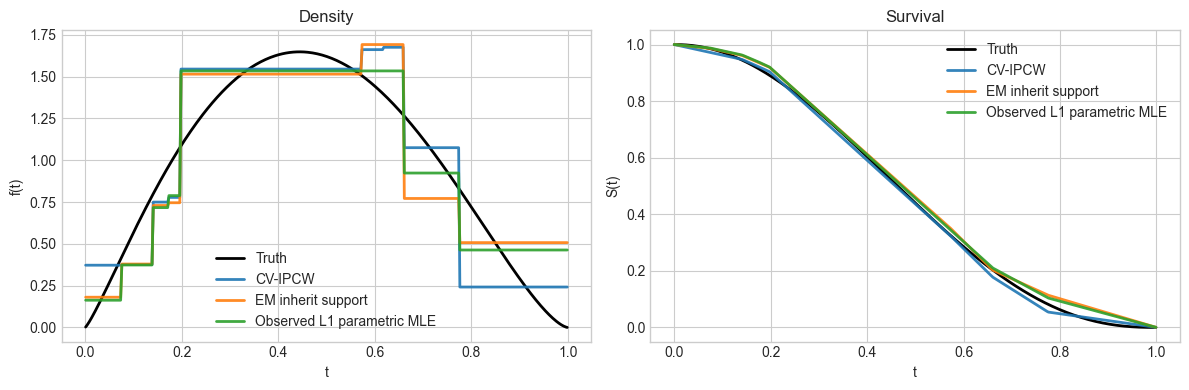

In [6]:
eval_grid = np.linspace(0.001, 0.999, 400)
surv_grid = np.linspace(0.0, 0.999, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(eval_grid, truth.density_fn(eval_grid), color="black", linewidth=2, label="Truth")
for label, estimator, color in [
    ("CV-IPCW", stage1_est, "tab:blue"),
    ("EM inherit support", stage2_est, "tab:orange"),
    ("Observed L1 parametric MLE", stage3_est, "tab:green"),
]:
    axes[0].plot(
        eval_grid,
        estimator.get_density_at_points(eval_grid),
        linewidth=2,
        alpha=0.9,
        color=color,
        label=label,
    )
axes[0].set_title("Density")
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].legend()

axes[1].plot(surv_grid, truth.survival_fn(surv_grid), color="black", linewidth=2, label="Truth")
for label, estimator, color in [
    ("CV-IPCW", stage1_est, "tab:blue"),
    ("EM inherit support", stage2_est, "tab:orange"),
    ("Observed L1 parametric MLE", stage3_est, "tab:green"),
]:
    axes[1].plot(
        surv_grid,
        evaluate_survival_on_grid(estimator, surv_grid),
        linewidth=2,
        alpha=0.9,
        color=color,
        label=label,
    )
axes[1].set_title("Survival")
axes[1].set_xlabel("t")
axes[1].set_ylabel("S(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
theta_ref = stage3_est.theta_hat.copy()
loglik_ref, grad_ref = stage3_est.observed_loglik_and_gradient(theta_ref, compute_grad=True)
coord = min(3, len(theta_ref) - 1)
step = 1e-6

theta_plus = theta_ref.copy()
theta_plus[coord] += step
theta_minus = theta_ref.copy()
theta_minus[coord] -= step

fd_grad = (
    stage3_est.observed_loglik_and_gradient(theta_plus, compute_grad=False)[0]
    - stage3_est.observed_loglik_and_gradient(theta_minus, compute_grad=False)[0]
) / (2.0 * step)

gradient_check_df = pd.DataFrame(
    [
        {
            "coordinate": coord,
            "observed_loglik_at_theta_hat": loglik_ref,
            "analytic_grad": float(grad_ref[coord]),
            "finite_diff_grad": float(fd_grad),
            "abs_error": float(abs(grad_ref[coord] - fd_grad)),
        }
    ]
)

display(gradient_check_df)

,coordinate,observed_loglik_at_theta_hat,analytic_grad,finite_diff_grad,abs_error
0,3,-13.032098,2.233177,2.233177,1.218159e-08


## Exact score diagnostics

This chunk compresses each fit onto the Stage 1 selected support, computes the observed-data score vector on that shared support, and then evaluates exact constant-L1 directional scores along tangent directions.


In [8]:
from haldensity.utils.basis import create_basis_functions


def compress_to_selected_support(estimator, *, coef_tol=1e-8):
    basis_order = int(estimator.basis_order)
    theta_full = np.asarray(estimator.theta_hat, dtype=float).copy()
    selected_knots = np.asarray(estimator.grid_points_hal_selected, dtype=float).copy()
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float).copy()
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + len(selected_knots), dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(selected_knots):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise ValueError(f"Unable to match selected knot {knot} in full working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]

    return {
        "theta_hat": theta_selected,
        "working_grid_points": selected_knots,
        "basis_order": basis_order,
        "include_intercept_in_constraint": bool(getattr(estimator, "include_intercept_in_constraint", False)),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "coef_tol": float(getattr(estimator, "tol", coef_tol)),
    }


def observed_loglik_and_gradient_from_state(state, observed_df, *, quadrature_n=2001, min_tail_mass=1e-12):
    theta = np.asarray(state["theta_hat"], dtype=float)
    working_grid = np.asarray(state["working_grid_points"], dtype=float)
    basis_order = int(state["basis_order"])
    if theta.size == 0 or working_grid.size == 0:
        raise ValueError("State must contain non-empty theta_hat and working_grid_points")

    grid = np.linspace(0.0, 1.0, int(quadrature_n))
    mid = 0.5 * (grid[:-1] + grid[1:])
    delta = np.diff(grid)

    basis_mid, _ = create_basis_functions(
        pd.DataFrame({"W1": mid}),
        working_grid,
        order=basis_order,
        include_intercept=True,
    )
    log_mid = basis_mid @ theta
    max_log = float(np.max(log_mid))
    weighted = np.exp(np.clip(log_mid - max_log, -700, 700)) * delta
    z = float(np.sum(weighted))
    if not np.isfinite(z) or z <= 0.0:
        raise ValueError("Observed likelihood normalizer must be positive")

    prob = weighted / z
    mu = prob @ basis_mid
    log_norm = max_log + float(np.log(z))

    ll = 0.0
    grad = -observed_df.shape[0] * mu

    event_times = np.asarray(observed_df.loc[observed_df["Delta"] == 1, "T"], dtype=float)
    if event_times.size:
        basis_event, _ = create_basis_functions(
            pd.DataFrame({"W1": event_times}),
            working_grid,
            order=basis_order,
            include_intercept=True,
        )
        ll += float(np.sum(basis_event @ theta - log_norm))
        grad += np.sum(basis_event, axis=0)

    censored_times = np.asarray(observed_df.loc[observed_df["Delta"] == 0, "T"], dtype=float)
    if censored_times.size:
        tail_mask = (mid[None, :] > censored_times[:, None]).astype(float)
        weighted_tails = tail_mask * prob[None, :]
        tail_masses = np.sum(weighted_tails, axis=1)
        safe_tail_masses = np.maximum(tail_masses, float(min_tail_mass))
        ll += float(np.sum(np.log(safe_tail_masses)))

        cond_means = weighted_tails @ basis_mid
        non_tiny = tail_masses > float(min_tail_mass)
        if np.any(non_tiny):
            cond_means[non_tiny] /= tail_masses[non_tiny, None]
        if np.any(~non_tiny):
            tail_centers = np.clip(0.5 * (censored_times[~non_tiny] + 1.0), 0.0, 1.0)
            fallback_basis, _ = create_basis_functions(
                pd.DataFrame({"W1": tail_centers}),
                working_grid,
                order=basis_order,
                include_intercept=True,
            )
            cond_means[~non_tiny] = fallback_basis
        grad += np.sum(cond_means, axis=0)

    n = float(observed_df.shape[0])
    return ll / n, grad / n


def sample_l1_constant_direction(theta, *, include_intercept_in_constraint=False, coef_tol=1e-8, rng, max_tries=64):
    start_idx = 0 if include_intercept_in_constraint else 1
    active = np.where(np.abs(theta[start_idx:]) > float(coef_tol))[0] + start_idx
    if active.size < 2:
        return None, active

    weights = np.abs(theta[active])
    denom = float(np.dot(weights, weights))
    if not np.isfinite(denom) or denom <= 0.0:
        return None, active

    for _ in range(int(max_tries)):
        h = rng.normal(size=active.size)
        h -= float(np.dot(h, weights)) / denom * weights
        max_abs = float(np.max(np.abs(h)))
        if np.isfinite(max_abs) and max_abs > 1e-10:
            return h / max_abs, active
    return None, active


def exact_constraint_score(theta, grad, h, active_idx):
    velocity = theta[active_idx] * h
    return float(np.dot(grad[active_idx], velocity))


shared_methods = [
    ("CV-IPCW", stage1_est),
    ("EM inherit support", stage2_est),
    ("Observed L1 parametric MLE", stage3_est),
]

rng = np.random.default_rng(SEED)
observed_rows = []
constraint_rows = []

for label, estimator in shared_methods:
    state = compress_to_selected_support(estimator)
    theta = np.asarray(state["theta_hat"], dtype=float)
    ll, grad = observed_loglik_and_gradient_from_state(state, observed_data)
    start_idx = 0 if state["include_intercept_in_constraint"] else 1
    penalized_grad = grad[start_idx:]
    observed_rows.append(
        {
            "method": label,
            "shared_support_knots": int(len(state["working_grid_points"])),
            "observed_loglik": float(ll),
            "max_abs_observed_score": float(np.max(np.abs(penalized_grad))) if penalized_grad.size else 0.0,
            "l2_observed_score": float(np.linalg.norm(penalized_grad)),
            "penalized_l1_norm": float(np.sum(np.abs(theta[start_idx:]))) if theta[start_idx:].size else 0.0,
        }
    )

    for direction_id in range(40):
        h, active_idx = sample_l1_constant_direction(
            theta,
            include_intercept_in_constraint=state["include_intercept_in_constraint"],
            coef_tol=state["coef_tol"],
            rng=rng,
        )
        if h is None:
            break
        score = exact_constraint_score(theta, grad, h, active_idx)
        constraint_rows.append(
            {
                "method": label,
                "direction_id": int(direction_id),
                "constraint_score": float(score),
                "abs_constraint_score": float(abs(score)),
                "active_penalized_count": int(active_idx.size),
            }
        )

observed_score_df = pd.DataFrame(observed_rows)
constraint_score_df = pd.DataFrame(constraint_rows)
constraint_summary_df = (
    constraint_score_df.groupby("method", as_index=False)
    .agg(
        n_directions=("direction_id", "count"),
        median_abs_constraint_score=("abs_constraint_score", "median"),
        max_abs_constraint_score=("abs_constraint_score", "max"),
    )
)

display(observed_score_df)
display(constraint_summary_df)

stage3_state = compress_to_selected_support(stage3_est)
_, stage3_grad = observed_loglik_and_gradient_from_state(stage3_state, observed_data)
stage3_observed_components_df = pd.DataFrame(
    {
        "coordinate": np.arange(stage3_grad.size, dtype=int),
        "gradient_component": stage3_grad,
    }
)
display(stage3_observed_components_df)


,method,shared_support_knots,observed_loglik,max_abs_observed_score,l2_observed_score,penalized_l1_norm
0,CV-IPCW,8,-0.079476,0.027489,0.060023,3.438636
1,EM inherit support,8,-0.070314,0.013551,0.029447,3.438638
2,Observed L1 parametric MLE,8,-0.068286,0.012038,0.027168,3.438638


,method,n_directions,median_abs_constraint_score,max_abs_constraint_score
0,CV-IPCW,40,0.007773,0.033275
1,EM inherit support,40,0.001575,0.004437
2,Observed L1 parametric MLE,40,0.001619,0.002844


,coordinate,gradient_component
0,0,-3.055334e-15
1,1,1.203750e-02
2,2,1.072046e-02
3,3,1.094998e-02
4,4,7.897936e-03
5,5,6.004178e-03
6,6,5.773810e-03
7,7,-9.808084e-03
8,8,-1.141940e-02


## What to look for

- `CV-IPCW` chooses the Stage 1 norm budget and working support.
- `EM inherit support` keeps that same support because `do_over_smooth=False` and `em_norm_factor=1.0`.
- `Observed L1 parametric MLE` also keeps the same support, but it fits the observed-data likelihood directly under the fixed-support L1 constraint and reports small or zero coefficients as diagnostics only.

If we later promote method 3 into the package, the notebook-local class here is the minimal behavior change to copy into `observed_mle.py`.